In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.9 MB/s eta 0:00:00


The ruptures library is a Python package dedicated to change point detection, which is useful for identifying abrupt changes in data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import breaks_cusumolsresid
import ruptures as rpt

**breaks_cusumolsresid** is a function within statsmodels used to perform the CUSUM (Cumulative Sum) test on OLS (Ordinary Least Squares) regression residuals. This test is a diagnostic tool to check for structural breaks in a time series regression model, meaning it helps detect if the relationship between variables changes abruptly over time.

# Loading Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_clean.csv to data_clean.csv


In [ ]:
df = pd.read_csv("data_clean.csv", index_col=0, parse_dates=True)

# The Chow Test

In [ ]:
def chow_test(df, breakpoint_date, y_var, x_vars):

    # Tests whether a structural break exists at breakpoint_date.
    A p-value below 0.05 means the break is statistically significant.

    X = sm.add_constant(df[x_vars])
    y = df[y_var]

    # Full sample regression
    full_model = sm.OLS(y, X).fit()
    rss_full = full_model.ssr

    # Split at breakpoint
    df1 = df[df.index < breakpoint_date]
    df2 = df[df.index >= breakpoint_date]

    X1 = sm.add_constant(df1[x_vars])
    X2 = sm.add_constant(df2[x_vars])

    model1 = sm.OLS(df1[y_var], X1).fit()
    model2 = sm.OLS(df2[y_var], X2).fit()

    rss1 = model1.ssr
    rss2 = model2.ssr

    # Chow test statistic
    k = len(x_vars) + 1  # number of parameters
    n = len(df)

    chow_stat = ((rss_full - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2*k))

    from scipy import stats
    p_value = 1 - stats.f.cdf(chow_stat, k, n - 2*k)

    return chow_stat, p_value

# Variables
Y_VAR = "BTC_ret"
X_VARS = ["SPX_ret", "^VIX", "DX-Y.NYB", "US10Y", "BREAKEVEN"]

# Test at COVID
chow_stat_covid, p_covid = chow_test(df, "2020-03-01", Y_VAR, X_VARS)
print(f"Chow Test — COVID (March 2020)")
print(f"  Statistic: {chow_stat_covid:.4f}")
print(f"  P-value:   {p_covid:.4f}")
print(f"  Significant: {'Yes' if p_covid < 0.05 else 'No'}")

print()

# Test at first rate hike
chow_stat_hike, p_hike = chow_test(df, "2022-03-01", Y_VAR, X_VARS)
print(f"Chow Test — Rate hike cycle (March 2022)")
print(f"  Statistic: {chow_stat_hike:.4f}")
print(f"  P-value:   {p_hike:.4f}")
print(f"  Significant: {'Yes' if p_hike < 0.05 else 'No'}")

Chow Test — COVID (March 2020)
  Statistic: 5.5031
  P-value:   0.0000
  Significant: Yes

Chow Test — Rate hike cycle (March 2022)
  Statistic: 2.3106
  P-value:   0.0315
  Significant: Yes


# The Bai-Parron Test

In [ ]:
# Run Bai-Perron style multiple break detection using ruptures
# The PELT algorithm detects optimal number of breaks

y = df[Y_VAR].values

# Detect breaks
model = rpt.Pelt(model="rbf").fit(y)
breakpoints = model.predict(pen=10)

# Convert index positions to dates
break_dates = [df.index[bp-1] for bp in breakpoints[:-1]]

print("Bai-Perron style break detection")
print(f"Number of breaks found: {len(break_dates)}")
print("Break dates detected:")
for d in break_dates:
    print(f"  {d.date()}")

Bai-Perron style break detection
Number of breaks found: 1
Break dates detected:
  2018-05-01


The results found only one break and placed it in May 2018 rather than at COVID or the rate hikes. This is interesting because May 2018 was actually a significant period in crypto markets. It was during the major crash following the 2017 Bitcoin bubble, when Bitcoin fell from nearly 20,000USD down to around 6,000USD. What the test analysis may be detecting here is a shift in Bitcoin's volatility regime rather than its macro sensitivity specifically. The Bai-Perron method is looking at Bitcoin returns broadly, and that 2018 crash represented a dramatic change in the return series itself.

# Plotting the breaks

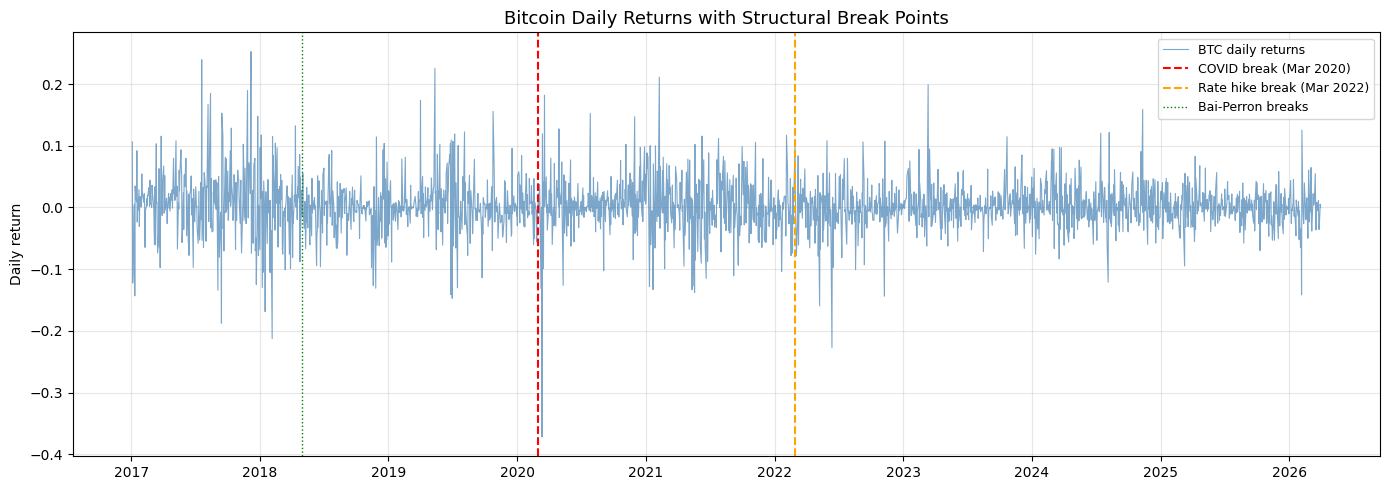

Saved as structural_breaks.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df[Y_VAR], color="steelblue", linewidth=0.8, alpha=0.7, label="BTC daily returns")

# Mark our Chow test dates
ax.axvline(pd.Timestamp("2020-03-01"), color="red", linewidth=1.5,
           linestyle="--", label="COVID break (Mar 2020)")
ax.axvline(pd.Timestamp("2022-03-01"), color="orange", linewidth=1.5,
           linestyle="--", label="Rate hike break (Mar 2022)")

# Mark Bai-Perron detected breaks
for i, d in enumerate(break_dates):
    label = "Bai-Perron breaks" if i == 0 else ""
    ax.axvline(d, color="green", linewidth=1, linestyle=":", label=label)

ax.set_title("Bitcoin Daily Returns with Structural Break Points", fontsize=13)
ax.set_ylabel("Daily return")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("structural_breaks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as structural_breaks.png")